In [1]:
from dotenv import load_dotenv
import os
import boto3
import awswrangler as wr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

load_dotenv()

# ── Config ──────────────────────────────────────────────────────────
S3_OUTPUT = "s3://pharma-bi-raw/athena-results/"
DATABASE  = "pharma_bi_db"

session = boto3.Session(
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_DEFAULT_REGION")
)

def run_query(sql: str) -> pd.DataFrame:
    """Run an Athena SQL query and return a pandas DataFrame."""
    return wr.athena.read_sql_query(
        sql=sql,
        database=DATABASE,
        s3_output=S3_OUTPUT,
        boto3_session=session
    )

# ── Plot style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'font.family':       'sans-serif',
})
PALETTE = ['#2C6FAC', '#3A9E6F', '#E07B3A', '#9B5EA0', '#C0392B']

# ── Sanity check ────────────────────────────────────────────────────
df_check = run_query("SELECT COUNT(*) AS n FROM fact_sales")
print(f"Connection OK — {df_check['n'].iloc[0]:,} rows in FactSales")

Connection OK — 62,139 rows in FactSales


In [4]:
query_category = """
SELECT
    dpr.category,
    COUNT(fs.salesid)                                                        AS transactions,
    SUM(fs.unitssold)                                                        AS total_units,
    ROUND(SUM(fs.revenueeur), 2)                                             AS total_revenue,
    ROUND(SUM(fs.margineur), 2)                                              AS total_margin,
    ROUND(AVG(fs.revenueeur), 2)                                             AS avg_revenue_per_tx,
    ROUND(AVG(CAST(fs.unitssold AS DOUBLE)), 2)                              AS avg_units_per_tx,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1)                  AS margin_pct,
    ROUND(SUM(fs.revenueeur) / SUM(SUM(fs.revenueeur)) OVER () * 100, 1)    AS revenue_share_pct
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid = dpr.productid
GROUP BY dpr.category
ORDER BY total_revenue DESC
"""

df_cat = run_query(query_category)
print(df_cat.to_string(index=False))


       category  transactions  total_units  total_revenue  total_margin  avg_revenue_per_tx  avg_units_per_tx  margin_pct  revenue_share_pct
   Prescription         13120        63277     2797015.76     613166.39              213.19              4.82        21.9               32.4
            OTC         19412       177686     1797329.55     528166.03               92.59              9.15        29.4               20.8
       Wellness         12483        89423     1712456.88     575117.00              137.18              7.16        33.6               19.8
  Personal Care         11073       101510     1454603.15     486875.18              131.36              9.17        33.5               16.8
Medical Devices          6051        13897      872571.97     217816.47              144.20              2.30        25.0               10.1


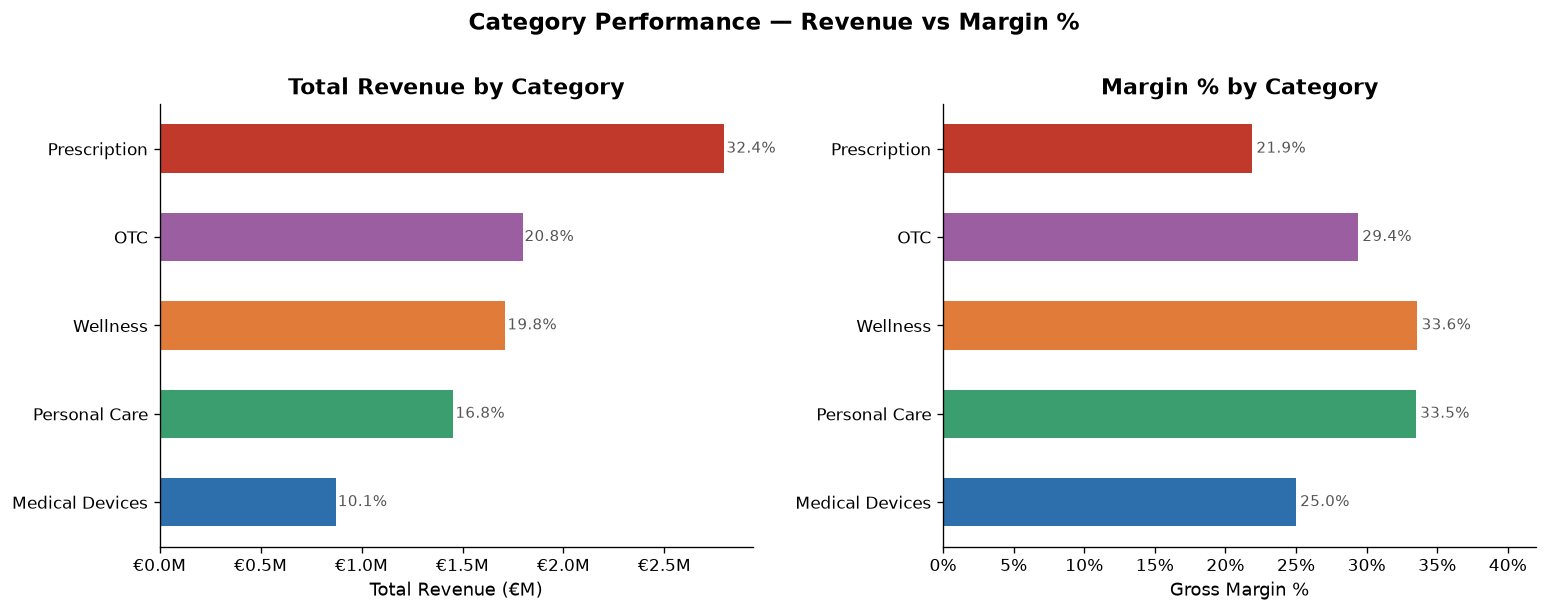

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Chart 1: Total revenue by category ──────────────────────────────
bars = axes[0].barh(
    df_cat['category'][::-1],
    df_cat['total_revenue'][::-1] / 1e6,
    color=PALETTE,
    height=0.55
)
axes[0].set_xlabel('Total Revenue (€M)')
axes[0].set_title('Total Revenue by Category')
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.1fM'))

# Annotate with revenue share %
for bar, share in zip(bars, df_cat['revenue_share_pct'][::-1]):
    axes[0].text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{share}%',
        va='center', fontsize=9, color='#555'
    )

# ── Chart 2: Margin % by category ───────────────────────────────────
bars2 = axes[1].barh(
    df_cat['category'][::-1],
    df_cat['margin_pct'][::-1],
    color=PALETTE,
    height=0.55
)
axes[1].set_xlabel('Gross Margin %')
axes[1].set_title('Margin % by Category')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
axes[1].set_xlim(0, 42)

# Annotate margin %
for bar, pct in zip(bars2, df_cat['margin_pct'][::-1]):
    axes[1].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center', fontsize=9, color='#555'
    )

plt.suptitle('Category Performance — Revenue vs Margin %', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/01_category_revenue_margin.png', bbox_inches='tight')
plt.show()

In [10]:
query_country = """
SELECT
    dp.country,
    COUNT(DISTINCT dp.pharmacyid)                                            AS pharmacy_count,
    COUNT(fs.salesid)                                                        AS transactions,
    ROUND(SUM(fs.revenueeur), 2)                                             AS total_revenue,
    ROUND(SUM(fs.margineur), 2)                                              AS total_margin,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1)                  AS margin_pct,
    ROUND(SUM(fs.revenueeur) / COUNT(DISTINCT dp.pharmacyid), 2)             AS avg_revenue_per_pharmacy,
    ROUND(SUM(fs.revenueeur) / SUM(SUM(fs.revenueeur)) OVER () * 100, 1)    AS revenue_share_pct
FROM fact_sales fs
JOIN dim_pharmacy dp ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.country
ORDER BY total_revenue DESC
"""

df_country = run_query(query_country)
print(df_country.to_string(index=False))


    country  pharmacy_count  transactions  total_revenue  total_margin  margin_pct  avg_revenue_per_pharmacy  revenue_share_pct
    Germany              22         10628     1567633.95     439238.04        28.0                  71256.09               18.2
     France              20         10187     1406811.74     393705.53        28.0                  70340.59               16.3
      Italy              18          9872     1332155.51     374344.20        28.1                  74008.64               15.4
    Belgium              14          8280     1246510.77     351005.49        28.2                  89036.48               14.4
Netherlands              11          6138      947748.20     265194.62        28.0                  86158.93               11.0
      Spain              12          5700      735600.24     204777.98        27.8                  61300.02                8.5
     Poland              13          6641      714235.73     200443.19        28.1                  5494

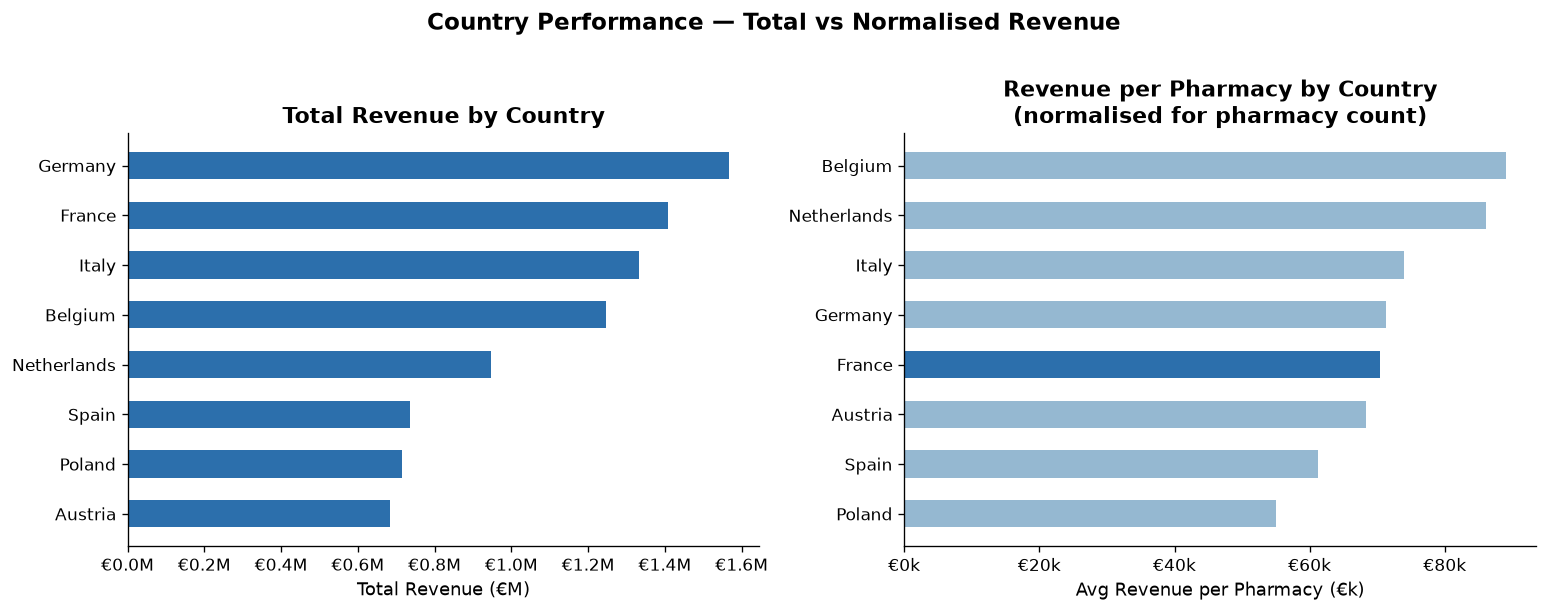

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Chart 1: Total revenue by country ───────────────────────────────
axes[0].barh(
    df_country['country'][::-1],
    df_country['total_revenue'][::-1] / 1e6,
    color='#2C6FAC',
    height=0.55
)
axes[0].set_xlabel('Total Revenue (€M)')
axes[0].set_title('Total Revenue by Country')
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.1fM'))

# ── Chart 2: Revenue per pharmacy — normalised view ──────────────────
# This is the more meaningful comparison — removes pharmacy count bias
colors = ['#2C6FAC' if v == df_country['avg_revenue_per_pharmacy'].max()
          else '#95b8d1' for v in df_country['avg_revenue_per_pharmacy']]

axes[1].barh(
    df_country.sort_values('avg_revenue_per_pharmacy')['country'],
    df_country.sort_values('avg_revenue_per_pharmacy')['avg_revenue_per_pharmacy'] / 1e3,
    color=colors,
    height=0.55
)
axes[1].set_xlabel('Avg Revenue per Pharmacy (€k)')
axes[1].set_title('Revenue per Pharmacy by Country\n(normalised for pharmacy count)')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))

plt.suptitle('Country Performance — Total vs Normalised Revenue', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/02_country_revenue.png', bbox_inches='tight')
plt.show()


In [12]:
query_phtype = """
SELECT
    dp.pharmacytype,
    COUNT(DISTINCT dp.pharmacyid)                                            AS pharmacy_count,
    COUNT(fs.salesid)                                                        AS transactions,
    ROUND(SUM(fs.revenueeur), 2)                                             AS total_revenue,
    ROUND(SUM(fs.revenueeur) / COUNT(DISTINCT dp.pharmacyid), 2)             AS avg_revenue_per_pharmacy,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1)                  AS margin_pct
FROM fact_sales fs
JOIN dim_pharmacy dp ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.pharmacytype
ORDER BY total_revenue DESC
"""

query_size = """
SELECT
    dp.storesizeband,
    COUNT(DISTINCT dp.pharmacyid)                                            AS pharmacy_count,
    COUNT(fs.salesid)                                                        AS transactions,
    ROUND(SUM(fs.revenueeur), 2)                                             AS total_revenue,
    ROUND(SUM(fs.revenueeur) / COUNT(DISTINCT dp.pharmacyid), 2)             AS avg_revenue_per_pharmacy,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1)                  AS margin_pct
FROM fact_sales fs
JOIN dim_pharmacy dp ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.storesizeband
ORDER BY total_revenue DESC
"""

df_phtype = run_query(query_phtype)
df_size   = run_query(query_size)

# Map S/M/L to readable labels
df_size['storesizeband'] = df_size['storesizeband'].map({'S': 'Small', 'M': 'Medium', 'L': 'Large'})

print("── By pharmacy type ──")
print(df_phtype.to_string(index=False))
print()
print("── By store size ──")
print(df_size.to_string(index=False))


── By pharmacy type ──
pharmacytype  pharmacy_count  transactions  total_revenue  avg_revenue_per_pharmacy  margin_pct
       Urban              50         29552     4125299.27                  82505.99        28.0
    Suburban              47         22403     3109295.56                  66155.22        28.1
       Rural              23         10184     1399382.48                  60842.72        28.1

── By store size ──
storesizeband  pharmacy_count  transactions  total_revenue  avg_revenue_per_pharmacy  margin_pct
       Medium              53         28181     3835577.81                  72369.39        28.0
        Large              25         19781     3172447.08                 126897.88        28.1
        Small              42         14177     1625952.42                  38713.15        28.0


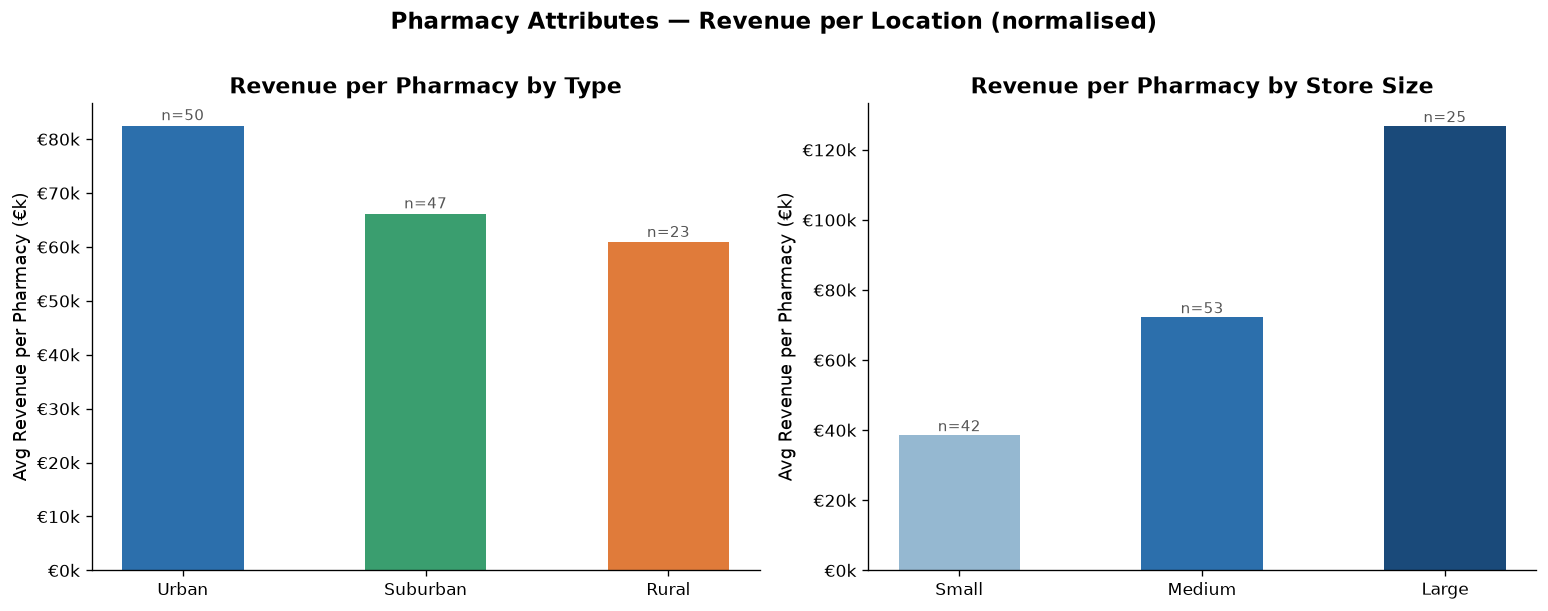

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Chart 1: Avg revenue per pharmacy by type ────────────────────────
axes[0].bar(
    df_phtype['pharmacytype'],
    df_phtype['avg_revenue_per_pharmacy'] / 1e3,
    color=['#2C6FAC', '#3A9E6F', '#E07B3A'],
    width=0.5
)
axes[0].set_ylabel('Avg Revenue per Pharmacy (€k)')
axes[0].set_title('Revenue per Pharmacy by Type')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))

for i, (val, count) in enumerate(zip(df_phtype['avg_revenue_per_pharmacy'], df_phtype['pharmacy_count'])):
    axes[0].text(i, val / 1e3 + 1, f'n={count}', ha='center', fontsize=9, color='#555')

# ── Chart 2: Avg revenue per pharmacy by store size ──────────────────
size_order = ['Small', 'Medium', 'Large']
df_size_sorted = df_size.set_index('storesizeband').reindex(size_order).reset_index()

axes[1].bar(
    df_size_sorted['storesizeband'],
    df_size_sorted['avg_revenue_per_pharmacy'] / 1e3,
    color=['#95b8d1', '#2C6FAC', '#1a4a7a'],
    width=0.5
)
axes[1].set_ylabel('Avg Revenue per Pharmacy (€k)')
axes[1].set_title('Revenue per Pharmacy by Store Size')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))

for i, (val, count) in enumerate(zip(df_size_sorted['avg_revenue_per_pharmacy'], df_size_sorted['pharmacy_count'])):
    axes[1].text(i, val / 1e3 + 1, f'n={count}', ha='center', fontsize=9, color='#555')

plt.suptitle('Pharmacy Attributes — Revenue per Location (normalised)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/03_pharmacy_type_size.png', bbox_inches='tight')
plt.show()

In [14]:
query_generic = """
SELECT
    dpr.isgeneric,
    COUNT(fs.salesid)                                       AS transactions,
    SUM(fs.unitssold)                                       AS total_units,
    ROUND(SUM(fs.revenueeur), 2)                            AS total_revenue,
    ROUND(AVG(fs.revenueeur), 2)                            AS avg_revenue_per_tx,
    ROUND(AVG(fs.margineur), 2)                             AS avg_margin_per_tx,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1) AS margin_pct,
    ROUND(SUM(fs.revenueeur) / SUM(fs.unitssold), 2)       AS revenue_per_unit
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid = dpr.productid
GROUP BY dpr.isgeneric
"""

df_generic = run_query(query_generic)

# Clean up label for display
df_generic['label'] = df_generic['isgeneric'].map({'Yes': 'Generic', 'No': 'Branded'})
print(df_generic.to_string(index=False))
metrics   = ['avg_revenue_per_tx', 'avg_margin_per_tx', 'margin_pct', 'revenue_per_unit']
labels    = ['Avg Revenue\nper Tx (€)', 'Avg Margin\nper Tx (€)', 'Margin %', 'Revenue\nper Unit (€)']



isgeneric  transactions  total_units  total_revenue  avg_revenue_per_tx  avg_margin_per_tx  margin_pct  revenue_per_unit   label
       No         52302       371106     7373585.94              140.98              40.15        28.5             19.87 Branded
      Yes          9837        74687     1260391.37              128.13              32.64        25.5             16.88 Generic


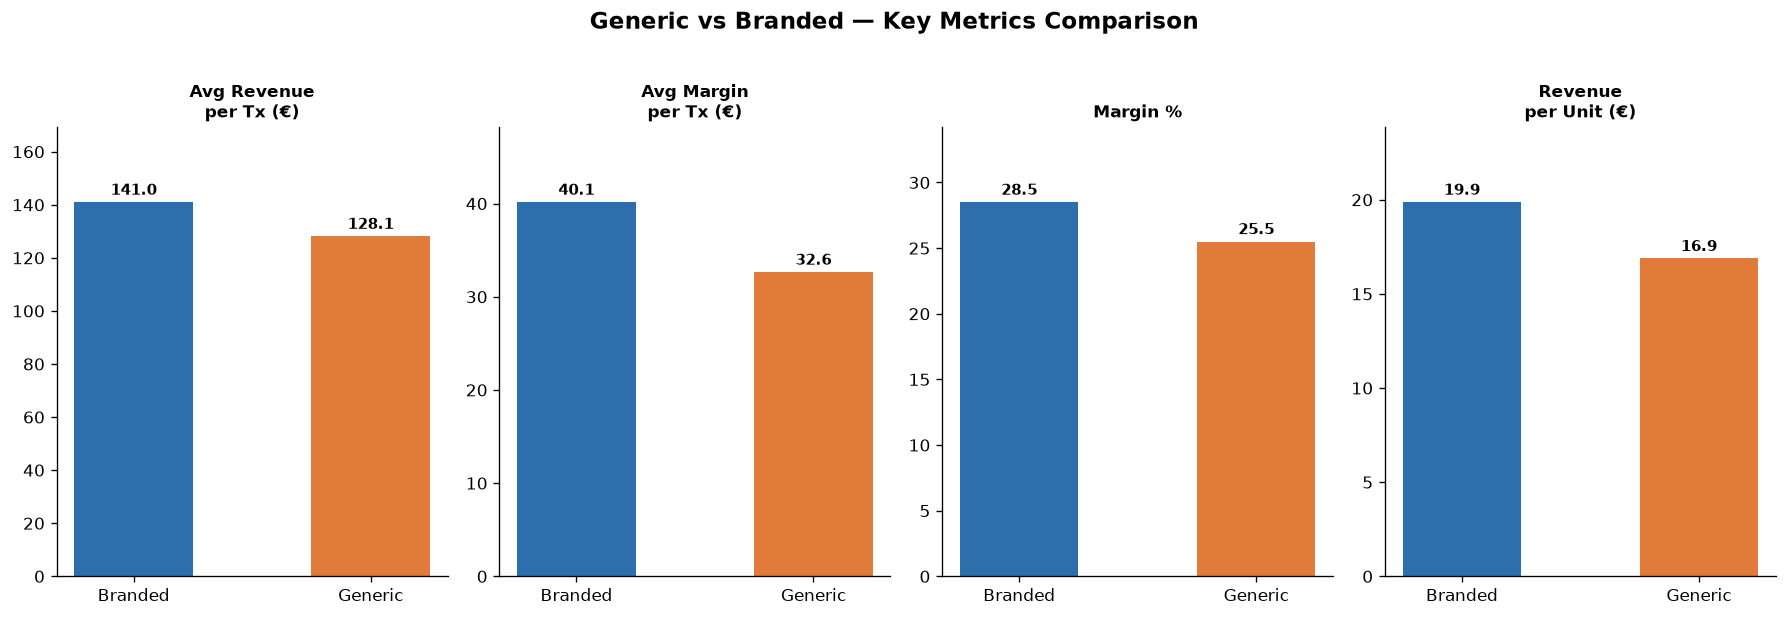

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

branded = df_generic[df_generic['isgeneric'] == 'No'].iloc[0]
generic = df_generic[df_generic['isgeneric'] == 'Yes'].iloc[0]

for ax, metric, label in zip(axes, metrics, labels):
    vals   = [branded[metric], generic[metric]]
    colors = ['#2C6FAC', '#E07B3A']
    bars   = ax.bar(['Branded', 'Generic'], vals, color=colors, width=0.5)
    ax.set_title(label, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.02,
            f'{v:.1f}',
            ha='center', fontsize=9, fontweight='bold'
        )
    ax.set_ylim(0, max(vals) * 1.2)

plt.suptitle('Generic vs Branded — Key Metrics Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/04_generic_vs_branded.png', bbox_inches='tight')
plt.show()

In [16]:
query_promo = """
SELECT
    fs.promoflag,
    COUNT(fs.salesid)                                       AS transactions,
    ROUND(AVG(CAST(fs.unitssold AS DOUBLE)), 2)             AS avg_units,
    ROUND(AVG(fs.revenueeur), 2)                            AS avg_revenue,
    ROUND(AVG(fs.margineur), 2)                             AS avg_margin,
    ROUND(SUM(fs.revenueeur), 2)                            AS total_revenue,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1) AS margin_pct
FROM fact_sales fs
GROUP BY fs.promoflag
ORDER BY fs.promoflag
"""

df_promo = run_query(query_promo)
df_promo['label'] = df_promo['promoflag'].map({'No': 'Non-Promo', 'Yes': 'Promo'})
print(df_promo.to_string(index=False))


promoflag  transactions  avg_units  avg_revenue  avg_margin  total_revenue  margin_pct     label
       No         54708       7.19       141.16       40.94     7722676.25        29.0 Non-Promo
      Yes          7431       7.02       122.64       24.43      911301.06        19.9     Promo


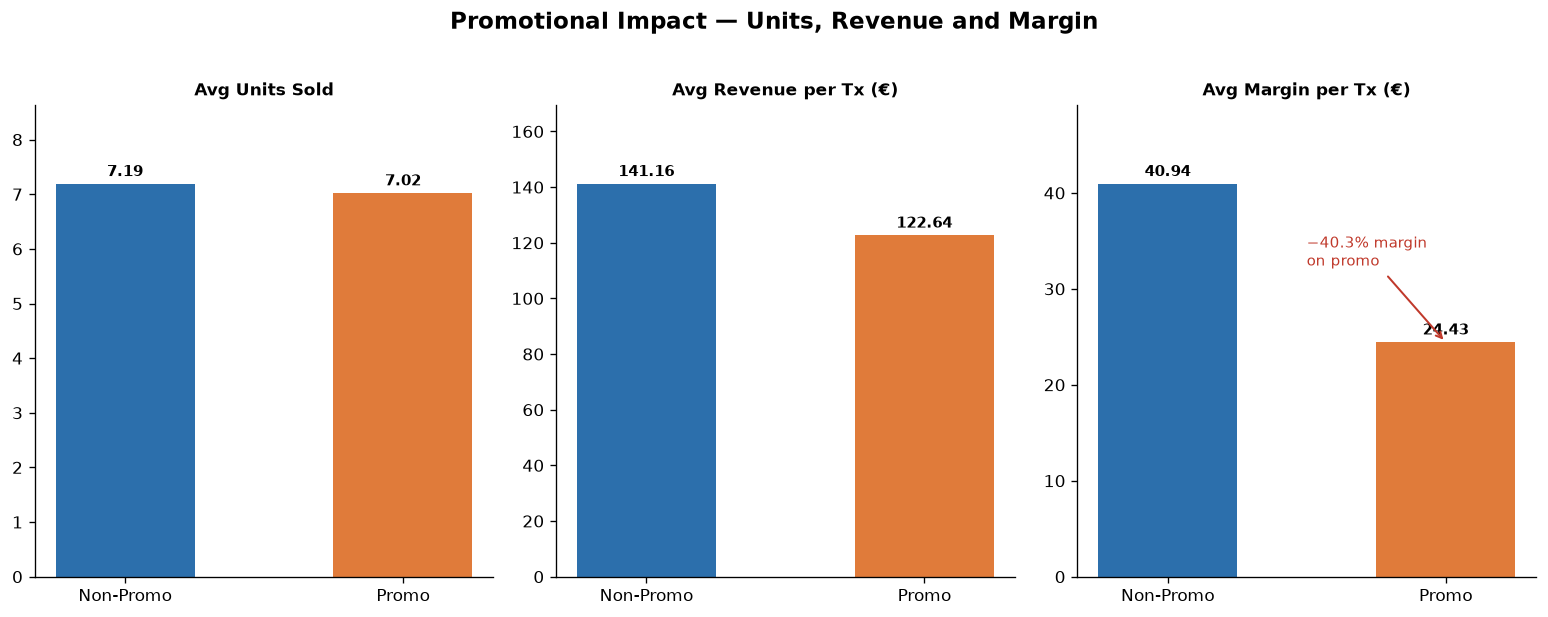

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

metrics = ['avg_units', 'avg_revenue', 'avg_margin']
titles  = ['Avg Units Sold', 'Avg Revenue per Tx (€)', 'Avg Margin per Tx (€)']
colors  = ['#2C6FAC', '#E07B3A']

non_promo = df_promo[df_promo['promoflag'] == 'No'].iloc[0]
promo     = df_promo[df_promo['promoflag'] == 'Yes'].iloc[0]

for ax, metric, title in zip(axes, metrics, titles):
    vals = [non_promo[metric], promo[metric]]
    bars = ax.bar(['Non-Promo', 'Promo'], vals, color=colors, width=0.5)
    ax.set_title(title, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.02,
            f'{v:.2f}',
            ha='center', fontsize=9, fontweight='bold'
        )
    ax.set_ylim(0, max(vals) * 1.2)

# Annotate the margin drop on the third chart
margin_drop = round((non_promo['avg_margin'] - promo['avg_margin']) / non_promo['avg_margin'] * 100, 1)
axes[2].annotate(
    f'−{margin_drop}% margin\non promo',
    xy=(1, promo['avg_margin']),
    xytext=(0.5, promo['avg_margin'] + 8),
    fontsize=9, color='#C0392B',
    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.2)
)

plt.suptitle('Promotional Impact — Units, Revenue and Margin', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/05_promo_impact.png', bbox_inches='tight')
plt.show()
# What this tells you:

# Promotions produce almost no uplift in units sold (7.02 promo vs 7.19 non-promo)
# Average margin collapses 40.3% on promo transactions (€40.94 → €24.43)
# Promotions are eroding margin with no compensating volume benefit — this is a key finding for Module 3


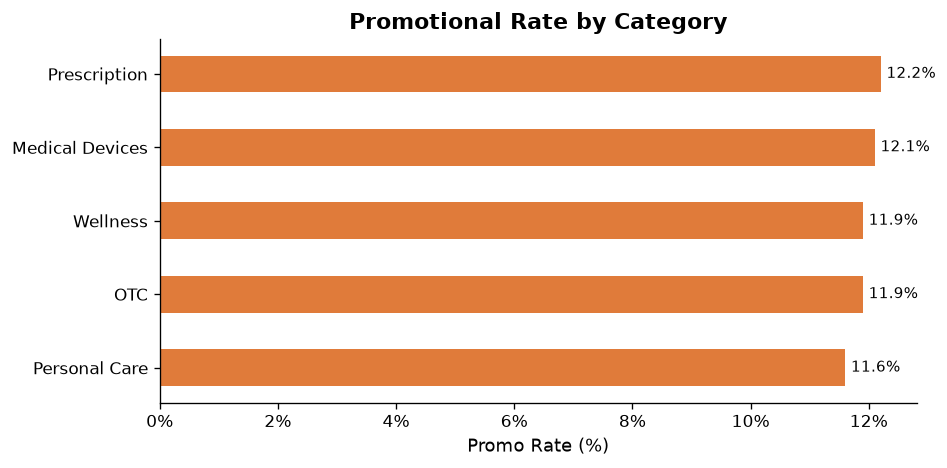

In [19]:
# Promo rate by category — which categories use promotions most
query_promo_cat = """
SELECT
    dpr.category,
    COUNT(CASE WHEN fs.promoflag = 'Yes' THEN 1 END)   AS promo_transactions,
    COUNT(fs.salesid)                                   AS total_transactions,
    ROUND(
        COUNT(CASE WHEN fs.promoflag = 'Yes' THEN 1 END) * 100.0 / COUNT(fs.salesid),
    1) AS promo_rate_pct
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid = dpr.productid
GROUP BY dpr.category
ORDER BY promo_rate_pct DESC
"""

df_promo_cat = run_query(query_promo_cat)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    df_promo_cat['category'][::-1],
    df_promo_cat['promo_rate_pct'][::-1],
    color='#E07B3A',
    height=0.5
)
ax.set_xlabel('Promo Rate (%)')
ax.set_title('Promotional Rate by Category', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

for bar, val in zip(bars, df_promo_cat['promo_rate_pct'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/06_promo_rate_by_category.png', bbox_inches='tight')
plt.show()


In [20]:
query_top_products = """
SELECT
    dpr.productname,
    dpr.category,
    ROUND(SUM(fs.revenueeur), 2)  AS total_revenue,
    SUM(fs.unitssold)             AS total_units,
    COUNT(fs.salesid)             AS transactions
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid = dpr.productid
GROUP BY dpr.productname, dpr.category
ORDER BY total_revenue DESC
LIMIT 10
"""

df_top_prod = run_query(query_top_products)

# Shorten product names for chart display
df_top_prod['short_name'] = df_top_prod['productname'].str[:30]



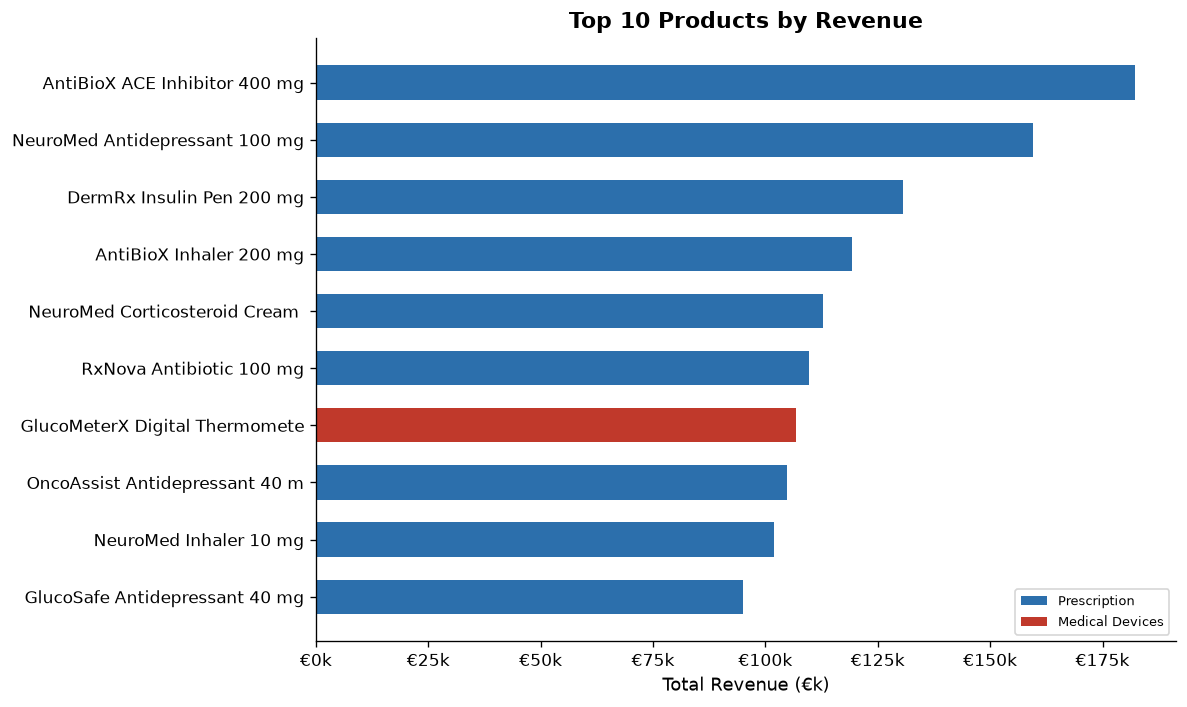

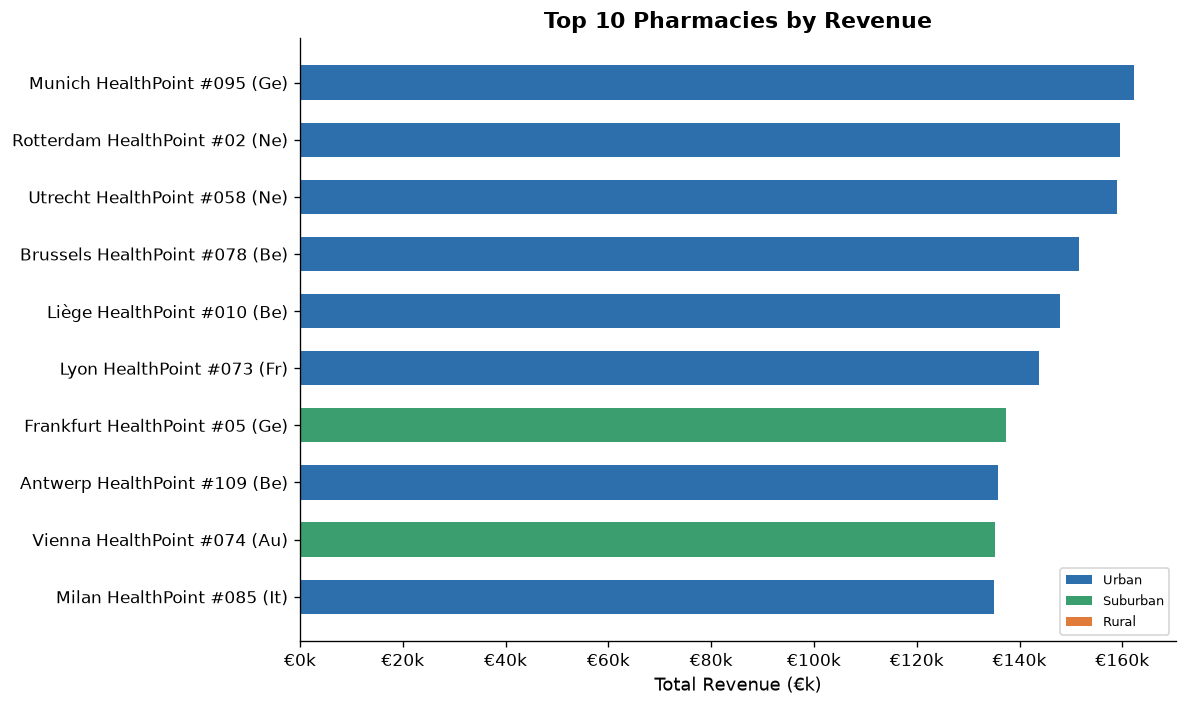

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

category_colors = {
    'Prescription':  '#2C6FAC',
    'OTC':           '#3A9E6F',
    'Wellness':      '#E07B3A',
    'Personal Care': '#9B5EA0',
    'Medical Devices': '#C0392B'
}
bar_colors = df_top_prod['category'].map(category_colors)

bars = ax.barh(
    df_top_prod['short_name'][::-1],
    df_top_prod['total_revenue'][::-1] / 1e3,
    color=bar_colors[::-1],
    height=0.6
)
ax.set_xlabel('Total Revenue (€k)')
ax.set_title('Top 10 Products by Revenue', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))

# Legend for categories
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in category_colors.items()
                   if k in df_top_prod['category'].values]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/08_top_products.png', bbox_inches='tight')
plt.show()
query_top_pharmacies = """
SELECT
    dp.pharmacyname,
    dp.country,
    dp.pharmacytype,
    ROUND(SUM(fs.revenueeur), 2)  AS total_revenue,
    COUNT(fs.salesid)             AS transactions
FROM fact_sales fs
JOIN dim_pharmacy dp ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.pharmacyname, dp.country, dp.pharmacytype
ORDER BY total_revenue DESC
LIMIT 10
"""

df_top_ph = run_query(query_top_pharmacies)
df_top_ph['label'] = df_top_ph['pharmacyname'].str[:25] + ' (' + df_top_ph['country'].str[:2] + ')'

fig, ax = plt.subplots(figsize=(10, 6))

type_colors = {'Urban': '#2C6FAC', 'Suburban': '#3A9E6F', 'Rural': '#E07B3A'}
ph_colors   = df_top_ph['pharmacytype'].map(type_colors)

bars = ax.barh(
    df_top_ph['label'][::-1],
    df_top_ph['total_revenue'][::-1] / 1e3,
    color=ph_colors[::-1],
    height=0.6
)
ax.set_xlabel('Total Revenue (€k)')
ax.set_title('Top 10 Pharmacies by Revenue', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))

legend_elements = [Patch(facecolor=v, label=k) for k, v in type_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/09_top_pharmacies.png', bbox_inches='tight')
plt.show()


In [22]:
summary = """
EDA SUMMARY
===========

Dataset: PharmaBI Retail Pharmacy Sales (2024-2025)
Total Revenue:    ~€8.63M across 62,139 transactions
Overall Margin %: 28.1%

CATEGORY INSIGHTS
-----------------
- Prescription: highest revenue (32.4%) but lowest margin % (21.9%)
- Wellness + Personal Care: best margin % (33.5-33.6%) — most profitable per euro
- OTC: highest transaction count and highest avg units per tx (9.15)
- Revenue rank ≠ profitability rank — key insight for Module 1

GEOGRAPHIC INSIGHTS
-------------------
- Germany leads total revenue (18.2%) — proportional to pharmacy count
- Margin % consistent across all 8 countries (27.8-28.2%)
- Normalised revenue per pharmacy reveals true market productivity

GENERIC VS BRANDED
------------------
- Branded outperforms generic on every metric
- Margin % gap: 28.5% branded vs 25.5% generic
- Generics are structurally less profitable, not just cheaper

PROMOTIONAL ACTIVITY
--------------------
- Promos: 12% of transactions but margin collapses 40.3%
- No meaningful volume uplift from promotions
- Hypothesis: promotions are margin-destructive

SEASONALITY
-----------
- Q3 (July-August) peak consistent across both years
- 2025 outperforms 2024 in every quarter
- Stable margin % across seasons — no pricing pressure

HYPOTHESES FOR ANALYSIS MODULES
--------------------------------
Module 1: Revenue rank ≠ profitability rank — separate the two stories
Module 2: Generics structurally less profitable — investigate by category
Module 3: Promos destroy margin with no volume uplift — quantify the cost
Module 4: Normalise by pharmacy count before comparing countries/types
Module 5: Q3 summer peak + 2025 growth trend to confirm in detailed analysis
Module 6: Stable seasonality pattern should make Prophet forecasts reliable

Charts saved to outputs/ folder.
"""

print(summary)


EDA SUMMARY

Dataset: PharmaBI Retail Pharmacy Sales (2024-2025)
Total Revenue:    ~€8.63M across 62,139 transactions
Overall Margin %: 28.1%

CATEGORY INSIGHTS
-----------------
- Prescription: highest revenue (32.4%) but lowest margin % (21.9%)
- Wellness + Personal Care: best margin % (33.5-33.6%) — most profitable per euro
- OTC: highest transaction count and highest avg units per tx (9.15)
- Revenue rank ≠ profitability rank — key insight for Module 1

GEOGRAPHIC INSIGHTS
-------------------
- Germany leads total revenue (18.2%) — proportional to pharmacy count
- Margin % consistent across all 8 countries (27.8-28.2%)
- Normalised revenue per pharmacy reveals true market productivity

GENERIC VS BRANDED
------------------
- Branded outperforms generic on every metric
- Margin % gap: 28.5% branded vs 25.5% generic
- Generics are structurally less profitable, not just cheaper

PROMOTIONAL ACTIVITY
--------------------
- Promos: 12% of transactions but margin collapses 40.3%
- No me